# Bitext Customer-Support Intent Classification — Modeling & Evaluation

Single end-to-end notebook merging `EDA Version 2.ipynb` + `nlp_preprocessing.ipynb` +
`modeling_classical.ipynb`, following the team workflow in
`Machine Learning - Bitext Dataset Team 3.pdf`:

| PDF step | Section here |
|---|---|
| Step 0 Environment setup | §1 Setup |
| Step 1 EDA | §2 EDA |
| Step 2 Advanced preprocessing (cleantext) | §3 Preprocessing |
| Step 3 Deduplication + splitting | §4 Split |
| — | §5 Validation experiments (evidence for the decisions below) |
| Step 4 Pipeline A — TF-IDF (mandatory) | §6 Features → §7b GridSearchCV |
| Step 5 Pipeline B — Word2Vec (optional) | §6 Features → §7a Benchmark |
| Step 6 DistilBERT (optional) | out of scope for this role |
| Step 7 Evaluation / error analysis / export | §8 Evaluation → §9 Export |

**Scope: modeling + evaluation only.** The exported `.pkl` artifacts (§9) are the
handoff point for the deployment teammate; no API/demo code lives here.

**Validated deviations from the PDF** (kept from prior experiment results, re-evidenced below):

| Topic | PDF | This notebook | Evidence |
|---|---|---|---|
| Char n-grams | (3,5) | **(2,5)** | §5 char-vs-word |
| Stopword removal | required | **none** (keep negations anyway) | §5 stopword experiment |
| Lemmatization | required | **none** | §5 lemma/stem experiment |
| Split | 80/20 | **80/10/10** stratified, seed 42 | §4 keeps test strictly held out |

## §1 Setup

In [1]:
# SECTION 1 - SETUP
# Imports everything up front, fixes SEED=42 so every result below is reproducible,
# creates the output folders (artifacts/, processed_data/, reports/figures/), and loads
# clean_text from preprocessing.py instead of redefining it (single source of truth).

%matplotlib inline
import json, random, string, time, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

import preprocessing as pp  # single source of truth for clean_text

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

BASE = Path.cwd()
RAW_CSV = BASE / "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
ART, PROC, FIG = BASE / "artifacts", BASE / "processed_data", BASE / "reports" / "figures"
for d in (ART, PROC, FIG):
    d.mkdir(parents=True, exist_ok=True)

for pkg in ("wordnet", "omw-1.4", "stopwords"):
    nltk.download(pkg, quiet=True)


def savefig(name):
    path = FIG / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("saved", path.relative_to(BASE))


print(f"SEED={SEED} | data: {RAW_CSV.name}")

SEED=42 | data: Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv


## §2 EDA — dataset inspection, imbalance, duplicates, lengths, flags & placeholders

In [2]:
# STEP 1 - LOAD DATA
# Read the raw CSV (26,872 rows x 5 columns) and sanity-check shape, column names
# and missing values before any analysis or modeling happens.

df = pd.read_csv(RAW_CSV)
print("shape:", df.shape)
print("columns:", list(df.columns))
print("\nnulls per column:")
print(df.isna().sum())
df.head(3)

shape: (26872, 5)
columns: ['flags', 'instruction', 'category', 'intent', 'response']

nulls per column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [3]:
# STEP 1 - DUPLICATE ANALYSIS
# Count duplicated instructions and prove that duplicates never carry conflicting
# intents (0 conflicts) - this is what makes it safe to deduplicate later in section 3.

n_dup_instr = int(df.duplicated(subset=["instruction"]).sum())
dup_rows = df[df.duplicated(subset=["instruction"], keep=False)]
n_conflict = int(dup_rows.groupby("instruction")["intent"].nunique().gt(1).sum())
print(f"duplicate instructions (rows beyond first): {n_dup_instr}")
print(f"duplicates with conflicting intent:        {n_conflict}")
print(f"exact full-row duplicates:                 {int(df.duplicated().sum())}")
print(f"categories: {df['category'].nunique()} | intents: {df['intent'].nunique()}")

duplicate instructions (rows beyond first): 2237
duplicates with conflicting intent:        0
exact full-row duplicates:                 0
categories: 11 | intents: 27


category imbalance (max:min): 6.30:1
intent imbalance    (max:min): 1.05:1  (intents are near-balanced)
largest category:  ACCOUNT (5986 rows)
smallest category: CANCEL (950 rows)


saved reports\figures\01_class_distribution.png


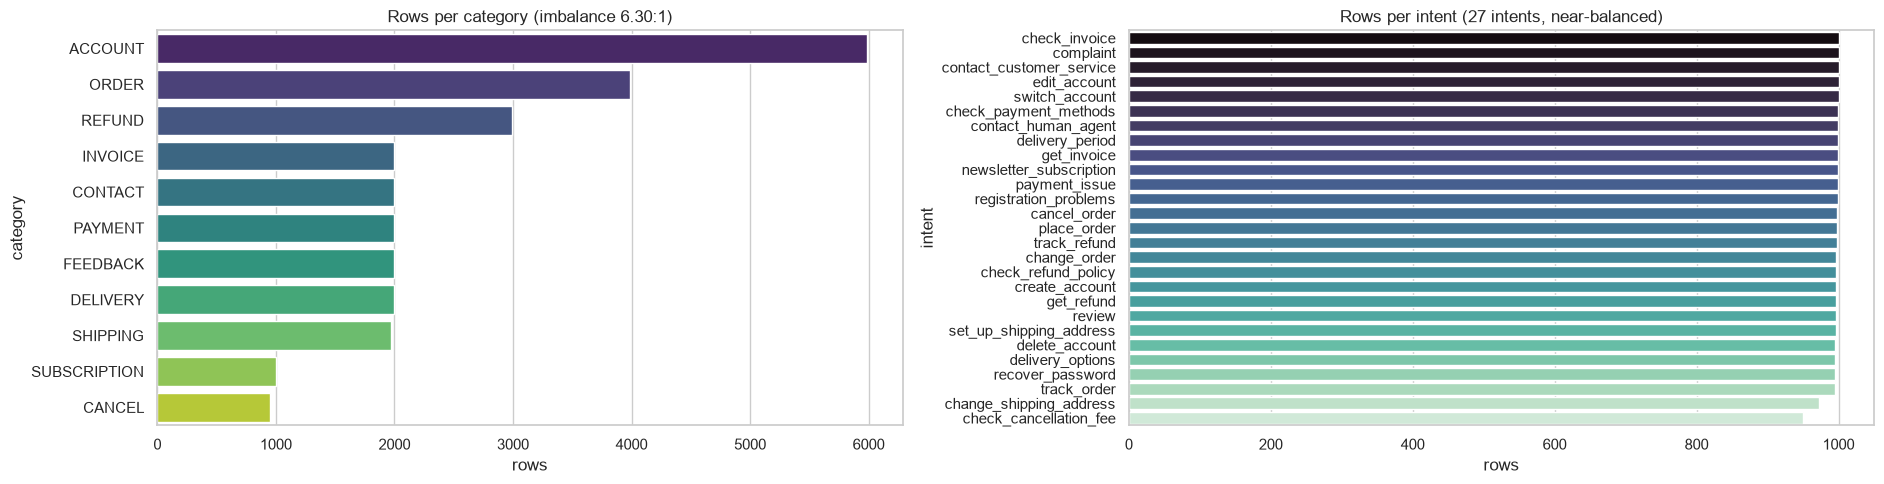

In [4]:
# STEP 1 - CLASS IMBALANCE
# Bar charts for the 11 categories and 27 intents plus the max:min ratio.
# Categories are imbalanced 6.30:1 (motivates class_weight / macro-F1 scoring);
# intents themselves are near-balanced, so intent-level stratification works cleanly.

cat_counts = df["category"].value_counts()
intent_counts = df["intent"].value_counts()
ratio_cat = cat_counts.max() / cat_counts.min()
ratio_int = intent_counts.max() / intent_counts.min()
print(f"category imbalance (max:min): {ratio_cat:.2f}:1")
print(f"intent imbalance    (max:min): {ratio_int:.2f}:1  (intents are near-balanced)")
print(f"largest category:  {cat_counts.idxmax()} ({cat_counts.max()} rows)")
print(f"smallest category: {cat_counts.idxmin()} ({cat_counts.min()} rows)")

fig, axes = plt.subplots(1, 2, figsize=(19, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title(f"Rows per category (imbalance {ratio_cat:.2f}:1)")
axes[0].set_xlabel("rows")
sns.barplot(x=intent_counts.values, y=intent_counts.index, hue=intent_counts.index,
            palette="mako", legend=False, ax=axes[1])
axes[1].set_title(f"Rows per intent ({len(intent_counts)} intents, near-balanced)")
axes[1].set_xlabel("rows")
plt.tight_layout()
savefig("01_class_distribution.png")
plt.show()

        n_words   n_chars
count  26872.00  26872.00
mean       8.69     46.89
std        2.61     10.90
min        1.00      6.00
25%        7.00     40.00
50%        9.00     48.00
75%       11.00     55.00
max       16.00     92.00


saved reports\figures\02_length_distributions.png


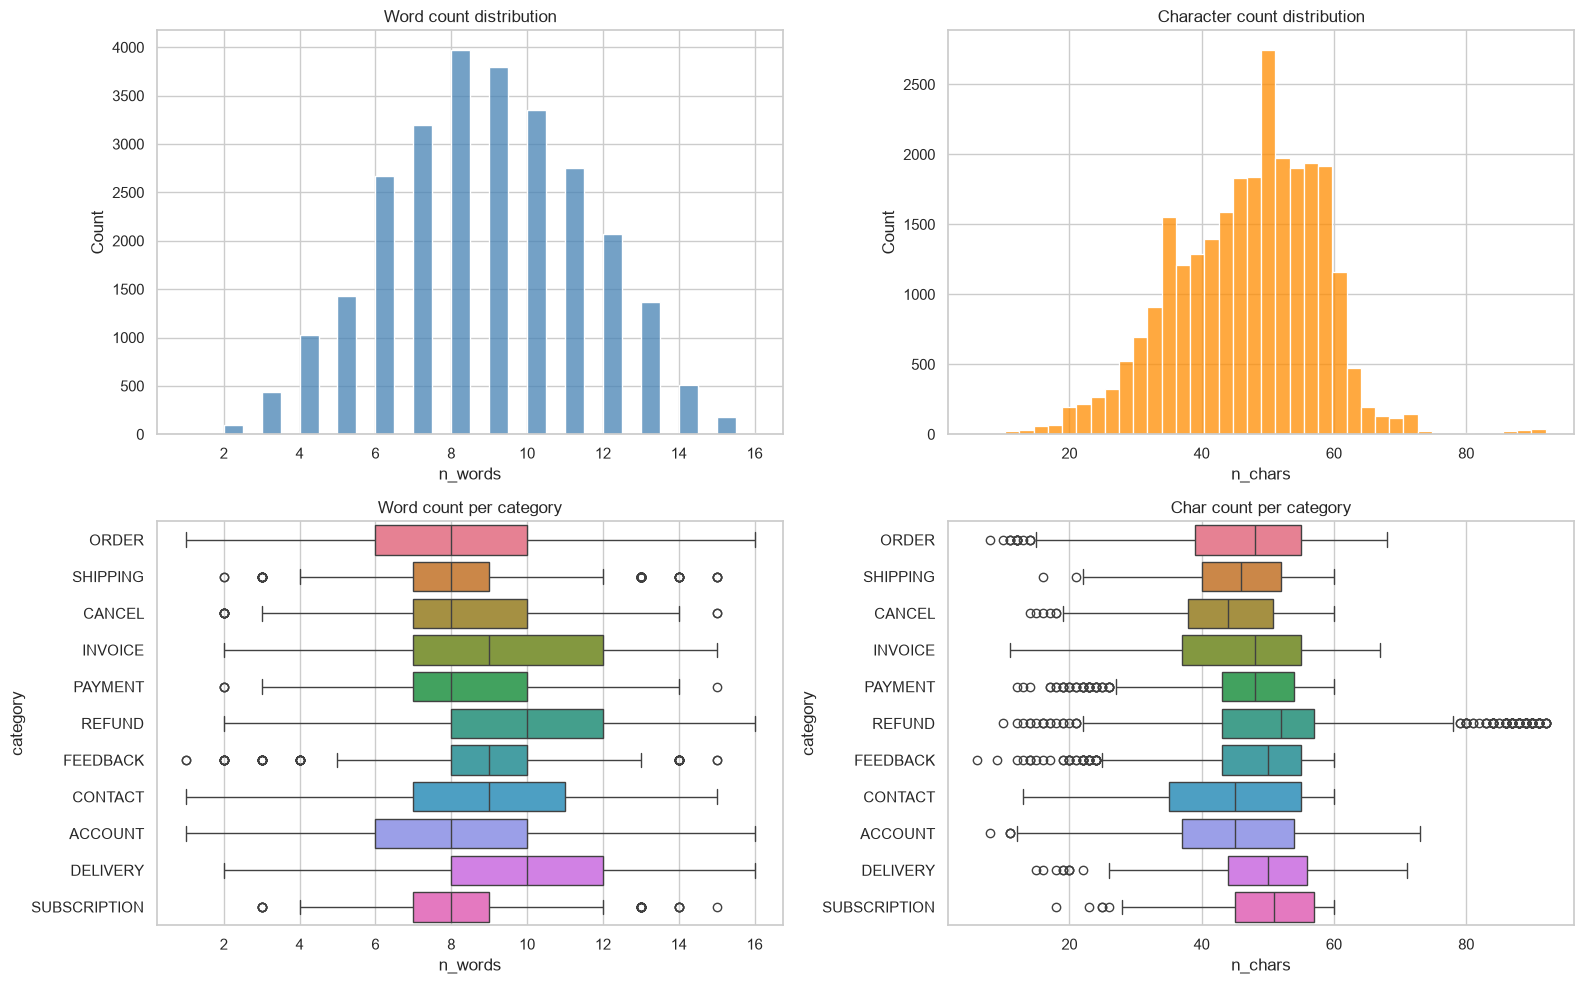

In [5]:
# STEP 1 - INPUT LENGTHS
# Word/char count distributions overall and per category. All instructions are short
# (<=16 words), which is exactly why char n-gram features capture them so well.

df["n_words"] = df["instruction"].str.split().str.len()
df["n_chars"] = df["instruction"].str.len()
print(df[["n_words", "n_chars"]].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df["n_words"], bins=30, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Word count distribution")
sns.histplot(df["n_chars"], bins=40, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Character count distribution")
sns.boxplot(data=df, y="category", x="n_words", hue="category", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Word count per category")
sns.boxplot(data=df, y="category", x="n_chars", hue="category", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Char count per category")
plt.tight_layout()
savefig("02_length_distributions.png")
plt.show()

unique flag codes: 14
flags
B    26872
L    24115
Q     8968
I     7839
Z     5286
M     4920
C     2646
K     2227
E     1882
P     1329
W     1288
N      463
S      417
V       77

rows containing placeholders: 6670 (24.8%)
top placeholders:
instruction
Order Number        2907
Account Type        1011
Person Name          887
Account Category     822
Refund Amount        624
Currency Symbol      372
Delivery City        234
Delivery Country     177


saved reports\figures\03_flags_placeholders.png


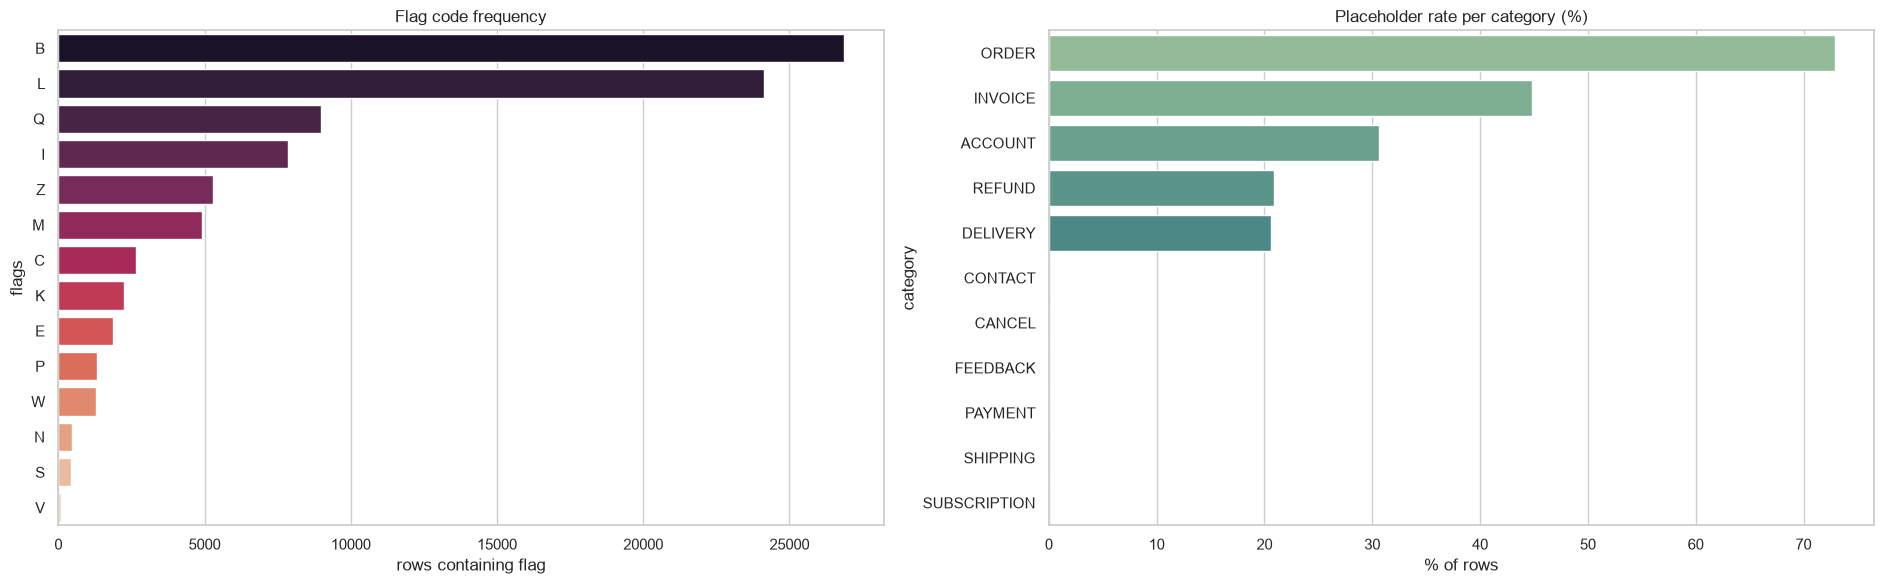

In [6]:
# STEP 1 - FLAGS AND PLACEHOLDERS
# Flags are single-letter codes (B, L, Q, Z, ...) marking data characteristics; the
# {{...}} placeholders (Order Number, Refund Amount, ...) appear in ~25% of rows and
# become ph_* tokens after clean_text. Placeholder rate differs strongly by category.

flag_chars = df["flags"].fillna("").str.findall(r"[A-Z]").explode().value_counts()
ph_rows = df["instruction"].str.contains(r"\{\{.*?\}\}", regex=True)
ph_top = df["instruction"].str.findall(r"\{\{(.*?)\}\}").explode().value_counts()
ph_by_cat = (df.assign(has_ph=ph_rows)
             .groupby("category")["has_ph"].mean().sort_values(ascending=False) * 100)

print(f"unique flag codes: {len(flag_chars)}")
print(flag_chars.to_string())
print(f"\nrows containing placeholders: {int(ph_rows.sum())} ({ph_rows.mean():.1%})")
print("top placeholders:")
print(ph_top.head(8).to_string())

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
sns.barplot(x=flag_chars.values, y=flag_chars.index, hue=flag_chars.index,
            palette="rocket", legend=False, ax=axes[0])
axes[0].set_title("Flag code frequency")
axes[0].set_xlabel("rows containing flag")
sns.barplot(x=ph_by_cat.values, y=ph_by_cat.index, hue=ph_by_cat.index,
            palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Placeholder rate per category (%)")
axes[1].set_xlabel("% of rows")
plt.tight_layout()
savefig("03_flags_placeholders.png")
plt.show()

total intents: 27 across 11 categories; mean 2.5 per category


saved reports\figures\04_intents_per_category.png


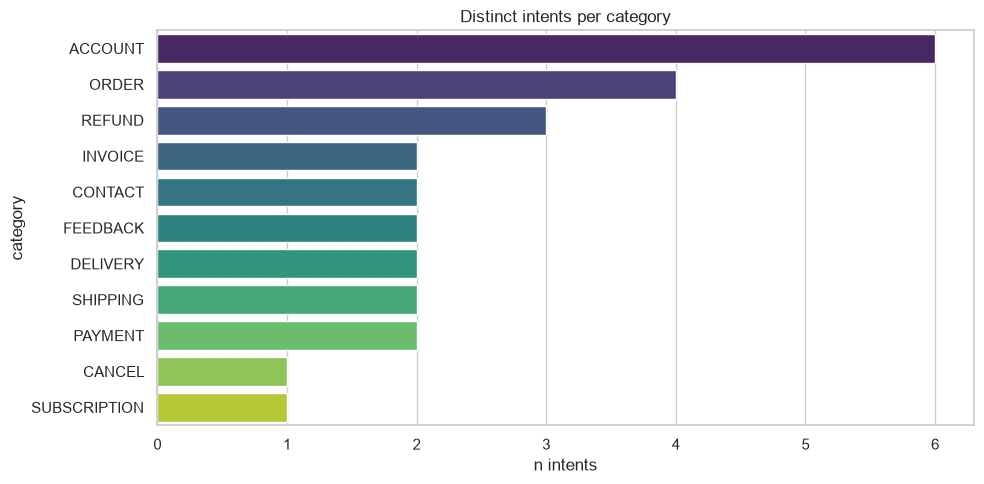

In [7]:
# STEP 1 - INTENTS PER CATEGORY
# How the 27 intents are distributed across the 11 categories (context for the
# hierarchical structure of the classification problem).

ipc = df.groupby("category")["intent"].nunique().sort_values(ascending=False)
print(f"total intents: {ipc.sum()} across {len(ipc)} categories; mean {ipc.mean():.1f} per category")
plt.figure(figsize=(10, 5))
sns.barplot(x=ipc.values, y=ipc.index, hue=ipc.index, palette="viridis", legend=False)
plt.title("Distinct intents per category")
plt.xlabel("n intents")
plt.tight_layout()
savefig("04_intents_per_category.png")
plt.show()

## §3 Preprocessing — `clean_text` (from `preprocessing.py`) + dedup

`clean_text` is **not** redefined here: `preprocessing.py` is the single source of truth
(`{{X}}` → `ph_x`, lowercase, whitespace collapse). Dedup on the cleaned instruction:
**26,872 → 24,274** rows; duplicate instructions never carry conflicting intents (§2).

In [8]:
# STEP 2 - CLEANING AND DEDUPLICATION
# Apply preprocessing.clean_text ({{X}} -> ph_x, lowercase, collapse whitespace) and
# drop duplicate cleaned instructions: 26,872 -> 24,274 rows. Prints a before/after
# summary, per-intent removal counts, and raw-vs-clean examples.

df["clean_instruction"] = df["instruction"].astype(str).map(pp.clean_text)

keep = ~df.duplicated(subset=["clean_instruction"], keep="first")
summary_tbl = pd.DataFrame(
    {"rows": [len(df), int(keep.sum())],
     "distinct clean texts": [df["clean_instruction"].nunique(),
                              df.loc[keep, "clean_instruction"].nunique()],
     "distinct intents": [df["intent"].nunique(), df.loc[keep, "intent"].nunique()]},
    index=["raw", "after dedup"],
)
print(summary_tbl.to_string())
removed = df.loc[~keep, "intent"].value_counts()
print(f"\nremoved duplicate rows: {int((~keep).sum())}")
print("removals per intent (top 10):")
print(removed.head(10).to_string())

print("\nclean_text examples (placeholders + case + whitespace):")
for t in ["I CAN'T   cancel my ORDER {{Order Number}}",
          "  where is   my refund for {{Refund Amount}} ",
          "need help with my {{Account Type}} please"]:
    print(f"  raw  : {t!r}\n  clean: {pp.clean_text(t)!r}")

              rows  distinct clean texts  distinct intents
raw          26872                 24274                27
after dedup  24274                 24274                27

removed duplicate rows: 2598
removals per intent (top 10):
intent
cancel_order        562
delivery_options    340
track_refund        306
edit_account        234
track_order         212
switch_account      164
change_order        141
create_account      122
get_invoice         111
delete_account       94

clean_text examples (placeholders + case + whitespace):
  raw  : "I CAN'T   cancel my ORDER {{Order Number}}"
  clean: "i can't cancel my order ph_order_number"
  raw  : '  where is   my refund for {{Refund Amount}} '
  clean: 'where is my refund for ph_refund_amount'
  raw  : 'need help with my {{Account Type}} please'
  clean: 'need help with my ph_account_type please'


## §4 Split — stratified 80/10/10, seed 42, integrity checks

Strictly held-out test set (the PDF's 80/20 would leave no separate val/test).
The split is **stratified on intent**; checks below prove zero text overlap,
full label coverage, negligible share drift, and exact dedup parity vs raw recompute.

In [9]:
# STEP 3 - STRATIFIED SPLIT (80/10/10, seed 42) + INTEGRITY CHECKS
# Splits deduplicated data into train/val/test (19,419 / 2,427 / 2,428) stratified by
# intent. Asserts zero text overlap between splits, all 27 labels present everywhere,
# negligible share drift, and that deduplication exactly reproduces when recomputed
# from raw. Splits are saved to processed_data/ so the split is reproducible later.

dedup_df = df.loc[keep].reset_index(drop=True)

train_df, temp_df = train_test_split(dedup_df, test_size=0.20, stratify=dedup_df["intent"],
                                     random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["intent"],
                                   random_state=SEED)
print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}"
      f"  (total {len(train_df) + len(val_df) + len(test_df)})")

# --- integrity checks -------------------------------------------------
sets = {n: set(d["clean_instruction"]) for n, d in
        [("train", train_df), ("val", val_df), ("test", test_df)]}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not sets[a] & sets[b], f"text overlap between {a} and {b}"
print("no text overlap between splits  OK")

labels = [set(d["intent"]) for d in (train_df, val_df, test_df)]
assert labels[0] == labels[1] == labels[2], "label sets differ across splits"
print(f"all {len(labels[0])} intents covered in every split  OK")

share = pd.concat([d["intent"].value_counts(normalize=True).rename(n) for n, d in
                   [("train", train_df), ("val", val_df), ("test", test_df)]], axis=1)
drift = (share.max(axis=1) - share.min(axis=1)) * 100
print(f"max per-intent share drift across splits: {drift.max():.3f} pp")

raw_again = pd.read_csv(RAW_CSV)
raw_again["ci"] = raw_again["instruction"].astype(str).map(pp.clean_text)
assert len(raw_again.drop_duplicates(subset=["ci"])) == len(dedup_df), "dedup parity failed"
print(f"dedup parity vs raw recompute  OK  ({len(dedup_df)} rows)")

cols = ["instruction", "clean_instruction", "category", "intent", "flags"]
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    part[cols].to_csv(PROC / f"{name}.csv", index=False)
print("saved", ", ".join(f"processed_data/{n}.csv" for n in ["train", "val", "test"]))

train 19419 | val 2427 | test 2428  (total 24274)
no text overlap between splits  OK
all 27 intents covered in every split  OK
max per-intent share drift across splits: 0.043 pp


dedup parity vs raw recompute  OK  (24274 rows)
saved processed_data/train.csv, processed_data/val.csv, processed_data/test.csv


## §5 Validation experiments — evidence for the decisions

The PDF mandates stopword removal, lemmatization, and char n-grams (3,5).
All three were previously shown to *hurt* on this dataset; the cells below re-run
the comparisons on the train/val split (test stays untouched) so the decisions are
reproducible rather than asserted. All use word TF-IDF (1,2) + LogisticRegression
unless stated otherwise.

In [10]:
# EXPERIMENT - STOPWORD REMOVAL (PDF says: remove them)
# Train word TF-IDF + LogisticRegression under three variants: no removal, remove all
# English stopwords, remove but keep negations. 'No removal' wins (0.9916 vs 0.9874),
# so the decision below is: keep every word.

# --- stopword experiment ------------------------------------------------
X_tr, X_va = train_df["clean_instruction"], val_df["clean_instruction"]
y_tr, y_va = train_df["intent"], val_df["intent"]

neg = {"not", "no", "never", "cannot", "unable", "can't", "don't", "won't",
       "couldn't", "shouldn't", "wouldn't", "isn't", "aren't", "wasn't",
       "weren't", "doesn't", "didn't", "n't"}
sw_en = set(stopwords.words("english"))
variants = {
    "no removal  <- chosen": None,
    "remove english stopwords": sw_en,
    "remove but keep negations": sw_en - neg,
}

rows = []
for name, removal in variants.items():
    tr = X_tr if removal is None else X_tr.map(
        lambda t: " ".join(w for w in t.split() if w not in removal))
    va = X_va if removal is None else X_va.map(
        lambda t: " ".join(w for w in t.split() if w not in removal))
    vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    Xt, Xv = vec.fit_transform(tr), vec.transform(va)
    clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xt, y_tr)
    pred = clf.predict(Xv)
    rows.append({"variant": name,
                 "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4),
                 "val accuracy": round(accuracy_score(y_va, pred), 4)})
pd.DataFrame(rows)

,variant,val macro-F1,val accuracy
0,no removal <- chosen,0.9916,0.9926
1,remove english stopwords,0.9874,0.9893
2,remove but keep negations,0.9874,0.9893


In [11]:
# EXPERIMENT - LEMMATIZATION / STEMMING (PDF says: lemmatize)
# Same setup, comparing no transformation vs lemmatize vs stem, plus a char (2,5)
# TF-IDF row. Both text transformations score lower than 'none', and char n-grams
# score highest overall -> decisions: no lemmatization, no stemming, use char (2,5).

# --- lemmatization / stemming experiment ---------------------------------
lemmatizer, stemmer = WordNetLemmatizer(), PorterStemmer()
text_variants = {
    "none  <- chosen": lambda t: t,
    "lemmatize": lambda t: " ".join(lemmatizer.lemmatize(w) for w in t.split()),
    "stem": lambda t: " ".join(stemmer.stem(w) for w in t.split()),
}
rows = []
for name, fn in text_variants.items():
    tr, va = X_tr.map(fn), X_va.map(fn)
    vec = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    Xt, Xv = vec.fit_transform(tr), vec.transform(va)
    clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xt, y_tr)
    pred = clf.predict(Xv)
    rows.append({"variant": name, "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4)})

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True, min_df=2)
Xt, Xv = vec.fit_transform(X_tr), vec.transform(X_va)
clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xt, y_tr)
pred = clf.predict(Xv)
rows.append({"variant": "char ngram (2,5)  <- chosen for Pipeline A",
             "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4)})
pd.DataFrame(rows)

,variant,val macro-F1
0,none <- chosen,0.9916
1,lemmatize,0.9913
2,stem,0.9906
3,"char ngram (2,5) <- chosen for Pipeline A",0.9971


In [12]:
# EXPERIMENT - WORD vs CHAR vs COMBINED TF-IDF (this cell fits the FINAL vectorizers)
# Word and char vectorizers are fitted on the TRAIN split only (never refit on val/test)
# and reused by every later section. Compares the three representations on validation
# and under 10% injected typos; also defines add_typos() used by all robustness checks.
# Result: word+char is best on clean text, char alone is most typo-robust.

# --- char vs word vs word+char (this cell fits the FINAL vectorizers) ----
WORD_PARAMS = dict(analyzer="word", ngram_range=(1, 2), sublinear_tf=True, min_df=2)
CHAR_PARAMS = dict(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True, min_df=2)


def add_typos(text, rate, seed):
    rng = random.Random(seed)
    return "".join(
        rng.choice(string.ascii_lowercase) if (ch.isalpha() and rng.random() < rate) else ch
        for ch in text)


w_vec = TfidfVectorizer(**WORD_PARAMS)
c_vec = TfidfVectorizer(**CHAR_PARAMS)
Xw_tr, Xw_va = w_vec.fit_transform(X_tr), w_vec.transform(X_va)
Xc_tr, Xc_va = c_vec.fit_transform(X_tr), c_vec.transform(X_va)
Xu_tr = sparse.hstack([Xw_tr, Xc_tr]).tocsr()
Xu_va = sparse.hstack([Xw_va, Xc_va]).tocsr()
print("word", Xw_tr.shape, "| char", Xc_tr.shape, "| union", Xu_tr.shape)

va_noisy10 = X_va.map(lambda t: add_typos(t, 0.10, SEED))
rows, clf_by_repr = [], {}
for name, Xt, Xv in [("word (1,2)", Xw_tr, Xw_va),
                     ("char (2,5)", Xc_tr, Xc_va),
                     ("word+char", Xu_tr, Xu_va)]:
    clf = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xt, y_tr)
    clf_by_repr[name] = clf
    pred = clf.predict(Xv)
    if name == "word+char":
        Xn = sparse.hstack([w_vec.transform(va_noisy10), c_vec.transform(va_noisy10)]).tocsr()
    elif name == "char (2,5)":
        Xn = c_vec.transform(va_noisy10)
    else:
        Xn = w_vec.transform(va_noisy10)
    rows.append({"representation": name,
                 "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4),
                 "val accuracy": round(accuracy_score(y_va, pred), 4),
                 "acc @10% typos": round(accuracy_score(y_va, clf.predict(Xn)), 4)})
pd.DataFrame(rows)

word (19419, 4974) | char (19419, 10106) | union (19419, 15080)


,representation,val macro-F1,val accuracy,acc @10% typos
0,"word (1,2)",0.9916,0.9926,0.8109
1,"char (2,5)",0.9971,0.9975,0.9699
2,word+char,0.9979,0.9984,0.9522


In [13]:
# EXPERIMENT - MULTI-SEED TYPO ROBUSTNESS
# Re-inject typos at 5/10/20% with 3 different seeds and measure accuracy for char vs
# word+char. Char alone holds up better under heavy noise; word-only features collapse
# (see previous cell) - the reason char n-grams are mandatory for this dataset.

# --- multi-seed typo robustness: char vs word+char ------------------------
rows = []
for name in ["char", "word+char"]:
    clf = clf_by_repr["char (2,5)" if name == "char" else name]
    for rate in [0.05, 0.10, 0.20]:
        accs = []
        for s in (1, 7, 42):
            noisy = X_va.map(lambda t: add_typos(t, rate, s))
            if name == "char":
                Xn = c_vec.transform(noisy)
            else:
                Xn = sparse.hstack([w_vec.transform(noisy), c_vec.transform(noisy)]).tocsr()
            accs.append(accuracy_score(y_va, clf.predict(Xn)))
        rows.append({"representation": name, "typo rate": rate,
                     "accuracy mean": round(float(np.mean(accs)), 4),
                     "accuracy std": round(float(np.std(accs)), 4)})
pd.DataFrame(rows)

,representation,typo rate,accuracy mean,accuracy std
0,char,0.05,0.9751,0.0074
1,char,0.10,0.9706,0.0096
2,char,0.20,0.8879,0.0688
3,word+char,0.05,0.9591,0.0121
4,word+char,0.10,0.9506,0.0148
5,word+char,0.20,0.8307,0.0932


## §6 Features — TF-IDF (Pipeline A) + Word2Vec (Pipeline B)

The word/char vectorizers fitted in §5 are fit on the **train split only** and reused
everywhere (never refit on val/test). Word2Vec is trained on train-split text only.

In [14]:
# STEP 5 (PDF) - PIPELINE B: WORD2VEC EMBEDDINGS (optional)
# Train a 128-dim Word2Vec on the train split only, mean-pool word vectors into one
# document vector per row, and keep them as sparse matrices for the benchmark below.
# The model is exported later in gensim's native format.

# --- Word2Vec document embeddings (train split only) ---------------------
w2v_corpus = [t.split() for t in X_tr]
t0 = time.time()
w2v_model = Word2Vec(sentences=w2v_corpus, vector_size=128, window=5, min_count=2,
                     workers=4, seed=SEED, epochs=20)
print(f"word2vec vocab={len(w2v_model.wv)} trained in {time.time() - t0:.1f}s")


def doc_vectors(texts, model, dim=128):
    out = np.zeros((len(texts), dim), dtype=np.float32)
    for i, t in enumerate(texts):
        vecs = [model.wv[w] for w in t.split() if w in model.wv]
        if vecs:
            out[i] = np.mean(vecs, axis=0)
    return out


W2V_tr = sparse.csr_matrix(doc_vectors(list(X_tr), w2v_model))
W2V_va = sparse.csr_matrix(doc_vectors(list(X_va), w2v_model))
print("w2v matrices:", W2V_tr.shape, W2V_va.shape)

word2vec vocab=1224 trained in 0.8s


w2v matrices: (19419, 128) (2427, 128)


## §7 Modeling

- **§7a** fixed-hyperparameter benchmark: 4 feature sets × {LogReg, LinearSVC, XGBoost} on train → val
- **§7b** mandatory Pipeline A `GridSearchCV` (5-fold `StratifiedKFold`, `scoring="f1_macro"`)
  on the word+char union: LinearSVC, LogisticRegression, **ComplementNB** (PDF-mandated, was missing from the original notebook)
- **§7c** typo robustness of the two best grid-search models

In [15]:
# STEP 7a - FIXED-HP BENCHMARK: 4 FEATURE SETS x 3 MODELS ON VALIDATION
# Trains LogReg / LinearSVC / XGBoost on word, char, word+char, and char+Word2Vec
# features with fixed hyperparameters (XGBoost uses early stopping on val).
# ~13 min total, most of it XGBoost; produces the metrics_benchmark.csv table.

# --- §7a benchmark loop --------------------------------------------------
le = LabelEncoder().fit(train_df["intent"])
y_tr_i, y_va_i = le.transform(y_tr), le.transform(y_va)

features = {
    "tfidf_word": (Xw_tr, Xw_va),
    "tfidf_char": (Xc_tr, Xc_va),
    "tfidf_word_char": (Xu_tr, Xu_va),
    "tfidf_char_w2v": (sparse.hstack([Xc_tr, W2V_tr]).tocsr(),
                       sparse.hstack([Xc_va, W2V_va]).tocsr()),
}
xgb_base = dict(n_estimators=500, learning_rate=0.1, max_depth=6, subsample=0.9,
                colsample_bytree=0.9, tree_method="hist", eval_metric="mlogloss",
                random_state=SEED, n_jobs=4, early_stopping_rounds=25)
model_factories = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=2000, random_state=SEED),
    "LinearSVC": lambda: LinearSVC(random_state=SEED),
    "XGBoost": lambda: xgb.XGBClassifier(**xgb_base),
}

bench = []
for fname, (Xtr, Xva) in features.items():
    for mname, factory in model_factories.items():
        t0 = time.time()
        m = factory()
        if mname == "XGBoost":
            m.fit(Xtr, y_tr_i, eval_set=[(Xva, y_va_i)], verbose=False)
            pred = le.inverse_transform(m.predict(Xva))
        else:
            m.fit(Xtr, y_tr)
            pred = m.predict(Xva)
        bench.append({"feature": fname, "model": mname,
                      "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4),
                      "val accuracy": round(accuracy_score(y_va, pred), 4),
                      "seconds": round(time.time() - t0, 1)})
        print(f"{fname:16s} {mname:18s} f1={bench[-1]['val macro-F1']:.4f} "
              f"acc={bench[-1]['val accuracy']:.4f}  ({bench[-1]['seconds']}s)", flush=True)
bench_df = pd.DataFrame(bench)

tfidf_word       LogisticRegression f1=0.9916 acc=0.9926  (0.9s)


tfidf_word       LinearSVC          f1=0.9922 acc=0.9934  (0.6s)


tfidf_word       XGBoost            f1=0.9794 acc=0.9806  (66.9s)


tfidf_char       LogisticRegression f1=0.9971 acc=0.9975  (2.3s)


tfidf_char       LinearSVC          f1=0.9987 acc=0.9992  (4.7s)


...

tfidf_word_char  LinearSVC          f1=0.9994 acc=0.9996  (5.5s)


tfidf_word_char  XGBoost            f1=0.9946 acc=0.9951  (581.7s)


tfidf_char_w2v   LogisticRegression f1=0.9941 acc=0.9946  (5.5s)


tfidf_char_w2v   LinearSVC          f1=0.9996 acc=0.9996  (10.7s)


tfidf_char_w2v   XGBoost            f1=0.9941 acc=0.9951  (428.7s)


feature,tfidf_char,tfidf_char_w2v,tfidf_word,tfidf_word_char
model,,,,
LinearSVC,0.9987,0.9996,0.9922,0.9994
LogisticRegression,0.9971,0.9941,0.9916,0.9979
XGBoost,0.9956,0.9941,0.9794,0.9946


saved reports\figures\05_benchmark_heatmap.png


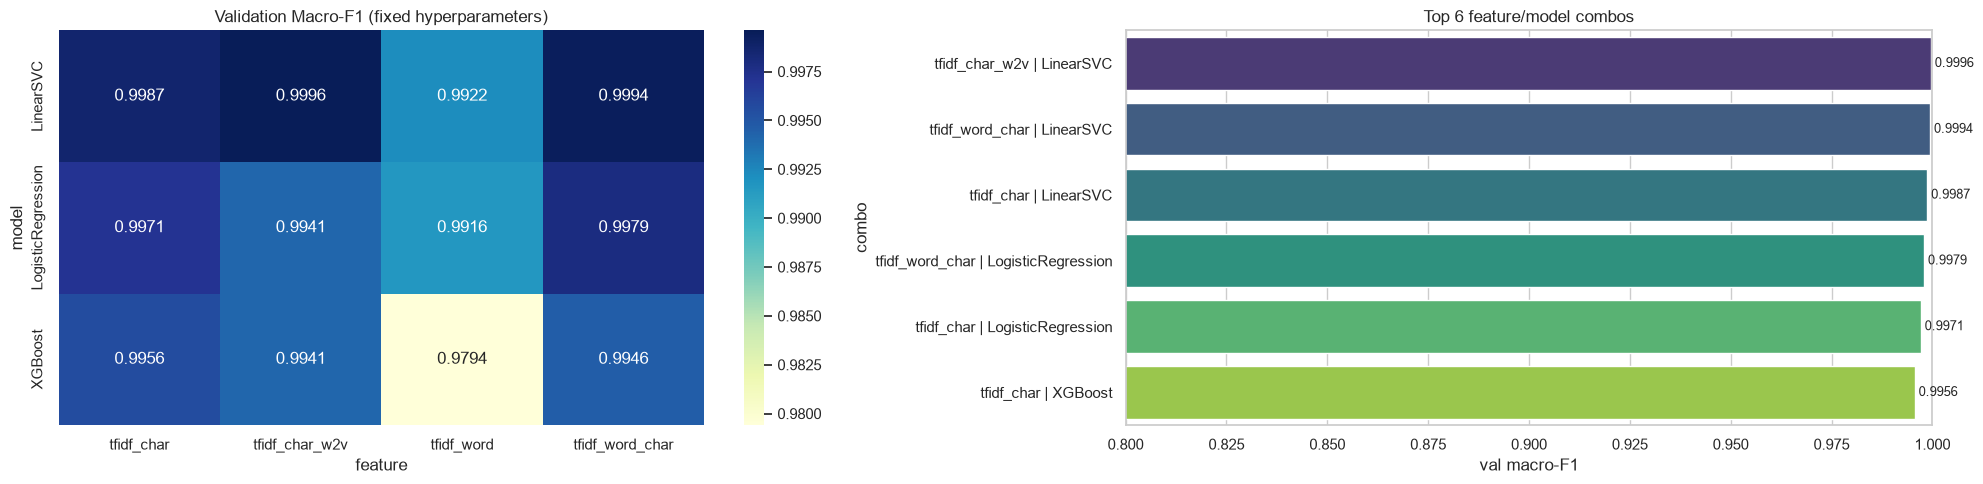

In [16]:
# BENCHMARK VISUALIZATION
# Pivot the benchmark results into a Macro-F1 heatmap and a bar chart of the top 6
# combos, then save the figure to reports/figures/.

piv = bench_df.pivot(index="model", columns="feature", values="val macro-F1")
display(piv.round(4))

top = bench_df.sort_values("val macro-F1", ascending=False).head(6).copy()
top["combo"] = top["feature"] + " | " + top["model"]
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.heatmap(piv, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Validation Macro-F1 (fixed hyperparameters)")
sns.barplot(data=top, x="val macro-F1", y="combo", hue="combo", legend=False, palette="viridis",
            ax=axes[1])
axes[1].set_title("Top 6 feature/model combos")
axes[1].set_xlim(min(0.8, top["val macro-F1"].min() - 0.02), 1.0)
for i, v in enumerate(top["val macro-F1"]):
    axes[1].text(v, i, f" {v:.4f}", va="center", fontsize=9)
plt.tight_layout()
savefig("05_benchmark_heatmap.png")
plt.show()

In [17]:
# STEP 7b - MANDATORY PIPELINE A: GridSearchCV (the model selection step)
# 5-fold StratifiedKFold, scoring='f1_macro', fit on TRAIN ONLY. LinearSVC and
# LogisticRegression over C x class_weight; ComplementNB over alpha (added because the
# PDF mandates it). n_jobs=-1 parallelizes the folds. Winner: LinearSVC C=10.

# --- §7b mandatory Pipeline A: GridSearchCV (word+char union) -------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_searches = {}

t0 = time.time()
grid_searches["LinearSVC"] = GridSearchCV(
    LinearSVC(random_state=SEED, max_iter=5000),
    {"C": [0.1, 1.0, 10.0], "class_weight": [None, "balanced"]},
    cv=cv, scoring="f1_macro", n_jobs=-1).fit(Xu_tr, y_tr)
gs = grid_searches["LinearSVC"]
print(f"LinearSVC   best={gs.best_params_}  cvF1={gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")

t0 = time.time()
grid_searches["LogisticRegression"] = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    {"C": [0.1, 1.0, 10.0], "class_weight": [None, "balanced"]},
    cv=cv, scoring="f1_macro", n_jobs=-1).fit(Xu_tr, y_tr)
gs = grid_searches["LogisticRegression"]
print(f"LogReg      best={gs.best_params_}  cvF1={gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")

t0 = time.time()
grid_searches["ComplementNB"] = GridSearchCV(
    ComplementNB(),
    {"alpha": [0.1, 0.5, 1.0]},
    cv=cv, scoring="f1_macro", n_jobs=-1).fit(Xu_tr, y_tr)
gs = grid_searches["ComplementNB"]
print(f"ComplementNB best={gs.best_params_}  cvF1={gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")

LinearSVC   best={'C': 10.0, 'class_weight': None}  cvF1=0.9988  (50s)


LogReg      best={'C': 10.0, 'class_weight': 'balanced'}  cvF1=0.9981  (19s)


ComplementNB best={'alpha': 0.1}  cvF1=0.9831  (0s)


In [18]:
# GRID SEARCH RESULTS TABLE
# Rank the three winners by cross-validated Macro-F1 and compare with the validation
# score - both must agree for the selection to be trusted. Selection uses CV/val only;
# the test split is still untouched at this point.

rows = []
for name, gs in grid_searches.items():
    pred = gs.best_estimator_.predict(Xu_va)
    rows.append({"model": name,
                 "best params": json.dumps(gs.best_params_, default=str),
                 "CV macro-F1 (5-fold)": round(gs.best_score_, 4),
                 "val macro-F1": round(f1_score(y_va, pred, average="macro"), 4),
                 "val accuracy": round(accuracy_score(y_va, pred), 4)})
cv_summary = (pd.DataFrame(rows)
              .sort_values("CV macro-F1 (5-fold)", ascending=False)
              .reset_index(drop=True))
cv_summary

,model,best params,CV macro-F1 (5-fold),val macro-F1,val accuracy
0,LinearSVC,"{""C"": 10.0, ""class_weight"": null}",0.9988,0.9990,0.9992
1,LogisticRegression,"{""C"": 10.0, ""class_weight"": ""balanced""}",0.9981,0.9990,0.9992
2,ComplementNB,"{""alpha"": 0.1}",0.9831,0.9817,0.9835


In [19]:
# STEP 7c - TYPO ROBUSTNESS OF THE TOP-2 GRID MODELS
# Same add_typos() stress test (0/5/10/20% x 3 seeds) on the two best grid-search
# models, evaluated on validation to confirm the choice degrades gracefully.

# --- §7c typo robustness of the two best grid-search models ---------------
rows = []
for name in cv_summary["model"].head(2).tolist():
    est = grid_searches[name].best_estimator_
    for rate in [0.0, 0.05, 0.10, 0.20]:
        if rate == 0:
            accs = [accuracy_score(y_va, est.predict(Xu_va))]
        else:
            accs = []
            for s in (1, 7, 42):
                noisy = X_va.map(lambda t: add_typos(t, rate, s))
                Xn = sparse.hstack([w_vec.transform(noisy), c_vec.transform(noisy)]).tocsr()
                accs.append(accuracy_score(y_va, est.predict(Xn)))
        rows.append({"model": name, "typo rate": rate,
                     "accuracy mean": round(float(np.mean(accs)), 4),
                     "accuracy std": round(float(np.std(accs)), 4)})
robust_df = pd.DataFrame(rows)
robust_df

,model,typo rate,accuracy mean,accuracy std
0,LinearSVC,0.00,0.9992,0.0000
1,LinearSVC,0.05,0.9674,0.0139
2,LinearSVC,0.10,0.9515,0.0244
3,LinearSVC,0.20,0.8188,0.1110
4,LogisticRegression,0.00,0.9992,0.0000
5,LogisticRegression,0.05,0.9665,0.0099
6,LogisticRegression,0.10,0.9566,0.0174
7,LogisticRegression,0.20,0.8333,0.0950


## §8 Final evaluation — held-out test set (evaluated exactly once)

Model selection is done on CV/val only (§7); the test split below is touched for the
first time in this notebook. Report: metrics, classification report, weakest classes,
confusion matrix, error inspection, and per-flag accuracy.

In [20]:
# STEP 8 - FINAL EVALUATION ON THE HELD-OUT TEST SET (first and only read of test)
# Uses the CV winner, transforms the test split, and reports accuracy, Macro-F1,
# weighted-F1, the full classification report, and the 5 weakest intents.

best_name = cv_summary.iloc[0]["model"]
best_gs = grid_searches[best_name]
best_est = best_gs.best_estimator_

Xte = sparse.hstack([w_vec.transform(test_df["clean_instruction"]),
                     c_vec.transform(test_df["clean_instruction"])]).tocsr()
y_te = test_df["intent"].reset_index(drop=True)
test_pred = best_est.predict(Xte)

test_metrics = {"model": best_name,
                "params": json.dumps(best_gs.best_params_, default=str),
                "accuracy": round(accuracy_score(y_te, test_pred), 4),
                "macro-F1": round(f1_score(y_te, test_pred, average="macro"), 4),
                "weighted-F1": round(f1_score(y_te, test_pred, average="weighted"), 4),
                "errors": int((test_pred != y_te.values).sum()),
                "n_test": int(len(y_te))}
print(json.dumps(test_metrics, indent=2))

report = pd.DataFrame(classification_report(y_te, test_pred, output_dict=True,
                                            zero_division=0)).T
display(report.round(4))
print("weakest 5 intents on the test set:")
display(report.loc[sorted(y_te.unique())].sort_values("f1-score").head(5).round(4))

{
  "model": "LinearSVC",
  "params": "{\"C\": 10.0, \"class_weight\": null}",
  "accuracy": 0.9992,
  "macro-F1": 0.9992,
  "weighted-F1": 0.9992,
  "errors": 2,
  "n_test": 2428
}


,precision,recall,f1-score,support
cancel_order,1.0000,1.0000,1.0000,43.0000
change_order,1.0000,0.9882,0.9941,85.0000
change_shipping_address,1.0000,1.0000,1.0000,96.0000
check_cancellation_fee,1.0000,1.0000,1.0000,94.0000
check_invoice,0.9892,1.0000,0.9946,92.0000
check_payment_methods,1.0000,1.0000,1.0000,100.0000
check_refund_policy,1.0000,1.0000,1.0000,98.0000
complaint,1.0000,1.0000,1.0000,100.0000
contact_customer_service,1.0000,1.0000,1.0000,99.0000
contact_human_agent,1.0000,1.0000,1.0000,98.0000


weakest 5 intents on the test set:


,precision,recall,f1-score,support
change_order,1.0000,0.9882,0.9941,85.0
get_invoice,1.0000,0.9888,0.9944,89.0
delete_account,0.9890,1.0000,0.9945,90.0
check_invoice,0.9892,1.0000,0.9946,92.0
check_cancellation_fee,1.0000,1.0000,1.0000,94.0


saved reports\figures\06_confusion_matrix_test.png


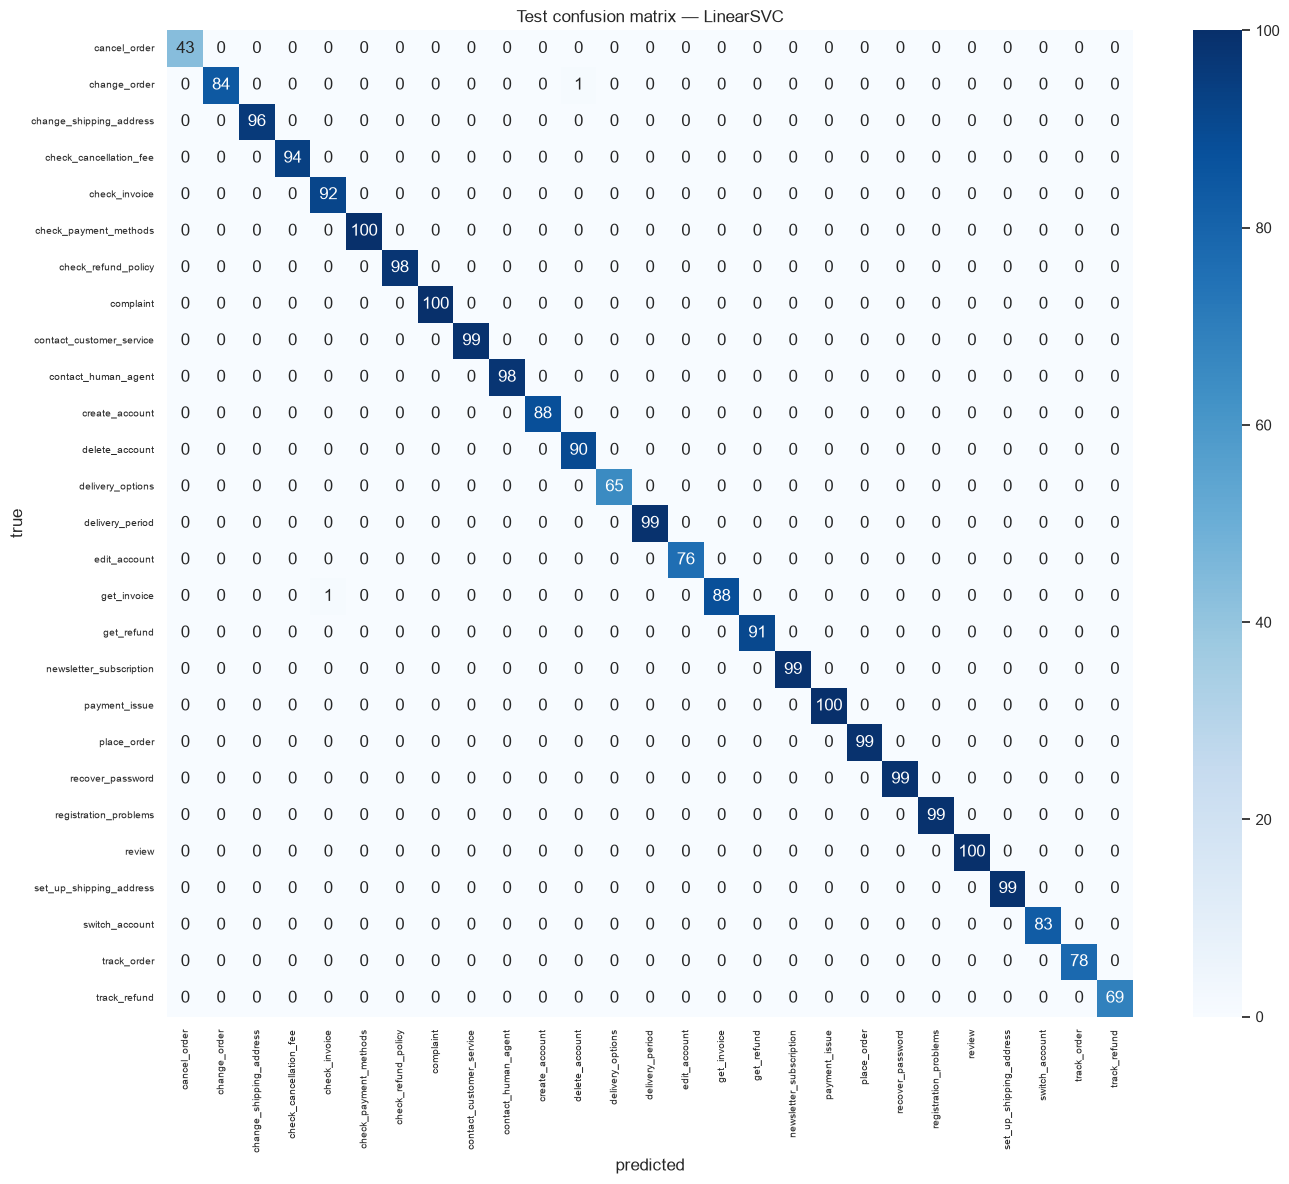

total test errors: 2 / 2428


In [21]:
# TEST CONFUSION MATRIX
# 27x27 heatmap of test predictions; off-diagonal cells are the misclassifications
# (2 total). Saved to reports/figures/ for the final report.

classes = sorted(y_te.unique())
cm = confusion_matrix(y_te, test_pred, labels=classes)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title(f"Test confusion matrix — {best_name}")
plt.tight_layout()
savefig("06_confusion_matrix_test.png")
plt.show()
print(f"total test errors: {int(cm.sum() - np.trace(cm))} / {len(y_te)}")

In [22]:
# TEST ERROR ANALYSIS + PER-FLAG ACCURACY
# Shows the exact misclassified instructions (both are heavily typo-ed inputs), then
# breaks accuracy down by flag code to check whether any flag is systematically harder.

err_mask = test_pred != y_te.values
errors = test_df.loc[err_mask, ["instruction", "flags", "category", "intent"]].copy()
errors = errors.reset_index(drop=True)
errors["predicted"] = test_pred[err_mask]
print(f"test errors: {len(errors)} / {len(y_te)}")
display(errors)

flag_acc = []
all_flags = test_df["flags"].fillna("").tolist()
for flag in sorted(set("".join(all_flags))):
    m = np.array([flag in f for f in all_flags])
    if m.sum() == 0:
        continue
    flag_acc.append({"flag": flag, "support": int(m.sum()),
                     "accuracy": round(float((test_pred[m] == y_te.values[m]).mean()), 4)})
flag_acc = pd.DataFrame(flag_acc).sort_values("support", ascending=False).reset_index(drop=True)
print("per-flag test accuracy:")
display(flag_acc)

test errors: 2 / 2428


,instruction,flags,category,intent,predicted
0,i nmeed assistance removing some products,BLMQZ,ORDER,change_order,delete_account
1,gedtting bill from {{Person Name}},BKLZ,INVOICE,get_invoice,check_invoice


per-flag test accuracy:


,flag,support,accuracy
0,B,2428,0.9992
1,L,2227,0.9991
2,Q,825,0.9988
3,I,730,1.0000
4,Z,494,0.9960
5,M,490,0.9980
6,C,280,1.0000
7,E,189,1.0000
8,K,147,0.9932
9,W,142,1.0000


## §9 Export — `.pkl` handoff artifacts

Files written to `artifacts/` for the deployment teammate. The pipeline object contains
the fitted word+char `FeatureUnion` **and** the classifier, so loading `bestmodel.pkl`
is enough to predict on raw (pre-cleaned) text — apply `preprocessing.clean_text` first.

In [23]:
# STEP 9 - EXPORT HANDOFF ARTIFACTS (.pkl FOR THE DEPLOYMENT TEAMMATE)
# Saves the full pipeline (TF-IDF union + classifier) as bestmodel.pkl, the vectorizer
# alone, the two alternative model pipelines, Word2Vec in native format, and all
# metrics as JSON/CSV. Everything lands in artifacts/ for the next teammate.

tfidf_union = FeatureUnion([("word", w_vec), ("char", c_vec)])
tfidf_union.fit(list(X_tr))  # same train data -> identical matrices as §5

PIPE_FILES = {"LinearSVC": "linearsvc_pipeline.pkl",
              "LogisticRegression": "logreg_pipeline.pkl",
              "ComplementNB": "complementnb_pipeline.pkl"}

best_pipe = Pipeline([("tfidf", tfidf_union), ("clf", best_est)])
joblib.dump(best_pipe, ART / "bestmodel.pkl")
joblib.dump(tfidf_union, ART / "tfidfvectorizer.pkl")
for name, gs in grid_searches.items():
    joblib.dump(Pipeline([("tfidf", tfidf_union), ("clf", gs.best_estimator_)]),
                ART / PIPE_FILES[name])
w2v_model.save(str(ART / "word2vec.model"))

results = {"seed": SEED,
           "splits": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
           "deduped_from": len(df),
           "best_model": best_name,
           "best_params": best_gs.best_params_,
           "cv_macro_f1": round(float(best_gs.best_score_), 4),
           "test_metrics": test_metrics,
           "grid_search": cv_summary.to_dict(orient="records"),
           "benchmark": bench_df.to_dict(orient="records")}
with open(ART / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, default=str, ensure_ascii=False)
cv_summary.to_csv(ART / "metrics_val.csv", index=False)
bench_df.to_csv(ART / "metrics_benchmark.csv", index=False)
pd.DataFrame([test_metrics]).to_csv(ART / "metrics_test.csv", index=False)

print("exported artifacts:")
for p in sorted(ART.glob("*")):
    print(f"  {p.relative_to(BASE)}  ({p.stat().st_size / 1024:.0f} KB)")

exported artifacts:
  artifacts\bestmodel.pkl  (3481 KB)
  artifacts\complementnb_pipeline.pkl  (6782 KB)
  artifacts\linearsvc_pipeline.pkl  (3481 KB)
  artifacts\logreg_pipeline.pkl  (3482 KB)
  artifacts\metrics_benchmark.csv  (1 KB)
  artifacts\metrics_test.csv  (0 KB)
  artifacts\metrics_val.csv  (0 KB)
  artifacts\results.json  (3 KB)
  artifacts\tfidfvectorizer.pkl  (299 KB)
  artifacts\word2vec.model  (1267 KB)


In [24]:
# SMOKE TEST - PROVE THE EXPORT WORKS
# Reload bestmodel.pkl from disk, predict on fresh raw strings (after clean_text, which
# deployment must also apply), and assert the reloaded pipeline reproduces the exact
# predictions of the in-memory model that was evaluated on the test set.

# --- smoke test: reload the handoff file and predict on fresh raw text ----
loaded = joblib.load(ART / "bestmodel.pkl")
samples = [
    "i want to cancel my order {{Order Number}}",
    "i need a refund for {{Refund Amount}} for my damaged item",
    "i can't log into my account",
    "can you tell me when my package will arrive",
]
for s in samples:
    print(f"{pp.clean_text(s)!r:66s} -> {loaded.predict([pp.clean_text(s)])[0]}")

probe = test_df["clean_instruction"].head(20)
probe_matrix = sparse.hstack([w_vec.transform(probe), c_vec.transform(probe)]).tocsr()
assert list(loaded.predict(probe)) == list(best_est.predict(probe_matrix)), "export mismatch!"
print("\nexported pipeline reproduces the evaluated model  OK")

'i want to cancel my order ph_order_number'                        -> cancel_order
'i need a refund for ph_refund_amount for my damaged item'         -> get_refund
"i can't log into my account"                                      -> recover_password
'can you tell me when my package will arrive'                      -> delivery_period

exported pipeline reproduces the evaluated model  OK


## Summary

**Headline results (seed 42):**
- **Best model: LinearSVC, C=10, class_weight=None on word+char TF-IDF union** (5-fold CV Macro-F1 **0.9988**)
- **Held-out test: accuracy 0.9992, Macro-F1 0.9992 — 2 errors / 2428** (both errors are heavily typo-ed inputs)
- Grid comparison: LinearSVC 0.9988 > LogisticRegression (C=10, balanced) 0.9981 > ComplementNB (alpha=0.1) 0.9831
- Benchmark (fixed hyperparams, val): word+char LinearSVC 0.9994, char+w2v LinearSVC 0.9996, XGBoost peaks at 0.9956 (char) but is 100x slower; Word2Vec alone never wins
- Typo robustness (val): char TF-IDF alone is the most robust (acc 0.97 @ 10% typos vs word-only 0.81); all models degrade at 20% typos
- Validation experiments reproduced: stopword removal 0.9916 → 0.9874, lemmatize 0.9913 / stem 0.9906 → both rejected; char (2,5) 0.9971 > word (0.9916)

**Decisions (deviations from the PDF documented at the top):**
no stopword removal, no lemmatization/stemming, char TF-IDF char_wb (2,5),
dedup on cleaned text (26,872 → 24,274), stratified 80/10/10 split (seed 42),
test set touched exactly once (§8).

**Handoff to deployment (next teammate):**

| File | Contents |
|---|---|
| \rtifacts/bestmodel.pkl\ | full pipeline: word+char \FeatureUnion\ + LinearSVC(C=10) |
| \rtifacts/tfidfvectorizer.pkl\ | fitted word+char TF-IDF union (15,080 features) |
| \rtifacts/linearsvc_pipeline.pkl\, \logreg_pipeline.pkl\, \complementnb_pipeline.pkl\ | alternative trained pipelines |
| \rtifacts/word2vec.model\ | gensim Word2Vec (native format) |
| \rtifacts/results.json\, \metrics_val.csv\, \metrics_benchmark.csv\, \metrics_test.csv\ | metrics + hyperparameters |
| eports/figures/*.png\ | 6 figures: EDA, benchmark heatmap, confusion matrix |
| \processed_data/{train,val,test}.csv\ | reproducible splits (19419/2427/2428) |

Deployment must call \preprocessing.clean_text\ on raw input before \predict(smoke-tested in the previous cell).